In [32]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn import tree
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

In [33]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\midha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\midha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\midha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [34]:
df = pd.read_csv("database.csv")
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [35]:
df['label'].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

In [36]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [37]:
df['tokens'] = df['text_'].apply(lambda x: x.split())

In [38]:
df['tokens_no_stopwords'] = df['tokens'].apply(lambda x: [word for word in x if word.lower() not in stop_words])

In [39]:
df['tokens_stemmed'] = df['tokens_no_stopwords'].apply(lambda x: [stemmer.stem(word) for word in x])

In [40]:
df['cleaned_text'] = df['tokens_stemmed'].apply(lambda x: ' '.join(x))

In [41]:
df.head()

,category,rating,label,text_,tokens,tokens_no_stopwords,tokens_stemmed,cleaned_text
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...","[Love, this!, Well, made,, sturdy,, and, very,...","[Love, this!, Well, made,, sturdy,, comfortabl...","[love, this!, well, made,, sturdy,, comfortabl...","love this! well made, sturdy, comfortable. lov..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...","[love, it,, a, great, upgrade, from, the, orig...","[love, it,, great, upgrade, original., I've, m...","[love, it,, great, upgrad, original., i'v, min...","love it, great upgrad original. i'v mine coupl..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,"[This, pillow, saved, my, back., I, love, the,...","[pillow, saved, back., love, look, feel, pillow.]","[pillow, save, back., love, look, feel, pillow.]",pillow save back. love look feel pillow.
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...","[Missing, information, on, how, to, use, it,, ...","[Missing, information, use, it,, great, produc...","[miss, inform, use, it,, great, product, price!]","miss inform use it, great product price!"
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,"[Very, nice, set., Good, quality., We, have, h...","[nice, set., Good, quality., set, two, months]","[nice, set., good, quality., set, two, month]",nice set. good quality. set two month


EDA with Sentiment Analyzer

In [42]:
import nltk
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\midha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [43]:
sia = SentimentIntensityAnalyzer()

In [44]:
def get_sentiment(text):
    sentiment_score = sia.polarity_scores(text)['compound']
    if sentiment_score > 0:
        return 'Positive'
    elif sentiment_score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['cleaned_text'].apply(get_sentiment)

In [45]:
sentiment_counts = df['sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

C:\Users\midha\AppData\Local\Temp\ipykernel_1736\2416989516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sentiment', y='Count', data=sentiment_counts, palette='viridis')


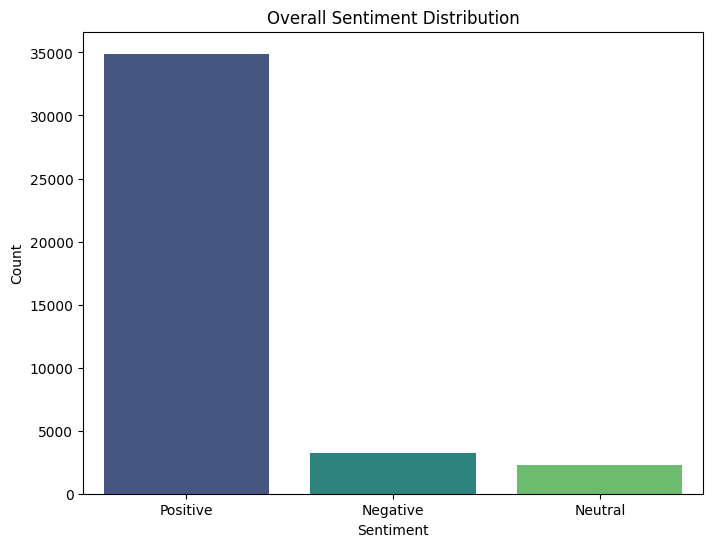

In [46]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Sentiment', y='Count', data=sentiment_counts, palette='viridis')
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

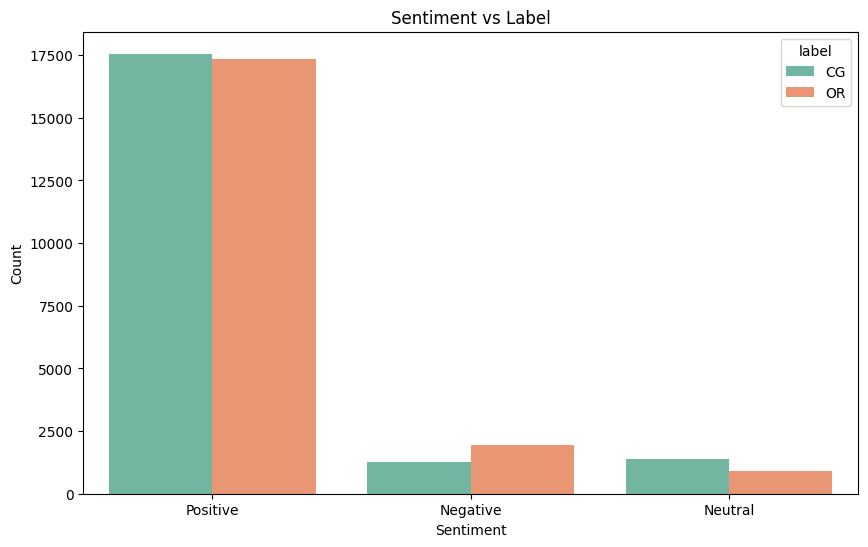

In [47]:
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', hue='label', data=df, palette='Set2')
plt.title('Sentiment vs Label')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

Preparing the data for training

In [48]:
X = df['cleaned_text']  # Feature (text data)
y = df['label']  # Target (label data)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [49]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Training the Random Forest Classifier

In [50]:
model = RandomForestClassifier()
model.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [51]:
RF_pred = model.predict(X_test_tfidf)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, RF_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, RF_pred))

Accuracy: 83.34%

Classification Report:
              precision    recall  f1-score   support

          CG       0.82      0.86      0.84      6066
          OR       0.85      0.81      0.83      6064

    accuracy                           0.83     12130
   macro avg       0.83      0.83      0.83     12130
weighted avg       0.83      0.83      0.83     12130



In [52]:
precision = precision_score(y_test, RF_pred, average='macro')  # or 'micro' or 'weighted'
recall = recall_score(y_test, RF_pred, average='macro')  # or 'micro' or 'weighted'
f1 = f1_score(y_test, RF_pred, average='macro')  # or 'micro' or 'weighted'

print(f"\nPrecision (Macro): {precision:.2f}")
print(f"Recall (Macro): {recall:.2f}")
print(f"F1-Score (Macro): {f1:.2f}")


Precision (Macro): 0.83
Recall (Macro): 0.83
F1-Score (Macro): 0.83


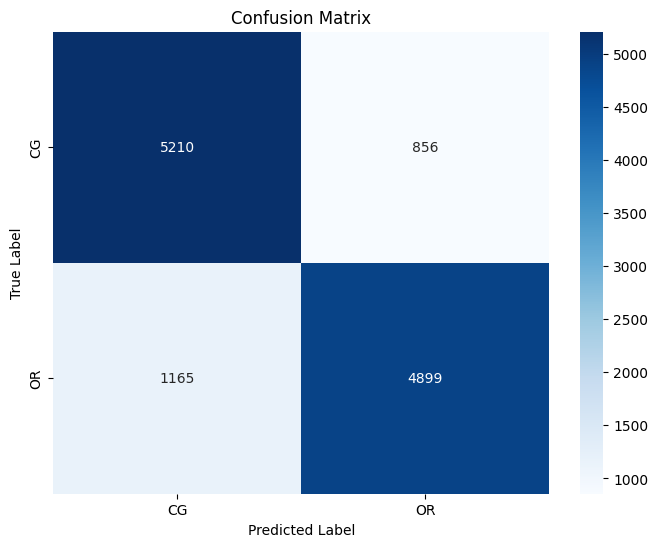

In [53]:
conf_matrix = confusion_matrix(y_test, RF_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

knn

In [54]:
model1= KNeighborsClassifier(n_neighbors=3)
model1.fit(X_train_tfidf, y_train)

KNeighborsClassifier(n_neighbors=3)

In [55]:
KNN_pred = model1.predict(X_test_tfidf)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, KNN_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, KNN_pred))

Accuracy: 50.29%

Classification Report:
              precision    recall  f1-score   support

          CG       0.50      0.96      0.66      6066
          OR       0.53      0.05      0.09      6064

    accuracy                           0.50     12130
   macro avg       0.52      0.50      0.37     12130
weighted avg       0.52      0.50      0.37     12130



In [56]:
precision = precision_score(y_test, KNN_pred, average='macro')  # or 'micro' or 'weighted'
recall = recall_score(y_test, KNN_pred, average='macro')  # or 'micro' or 'weighted'
f1 = f1_score(y_test, KNN_pred, average='macro')  # or 'micro' or 'weighted'

print(f"\nPrecision (Macro): {precision:.2f}")
print(f"Recall (Macro): {recall:.2f}")
print(f"F1-Score (Macro): {f1:.2f}")


Precision (Macro): 0.52
Recall (Macro): 0.50
F1-Score (Macro): 0.37


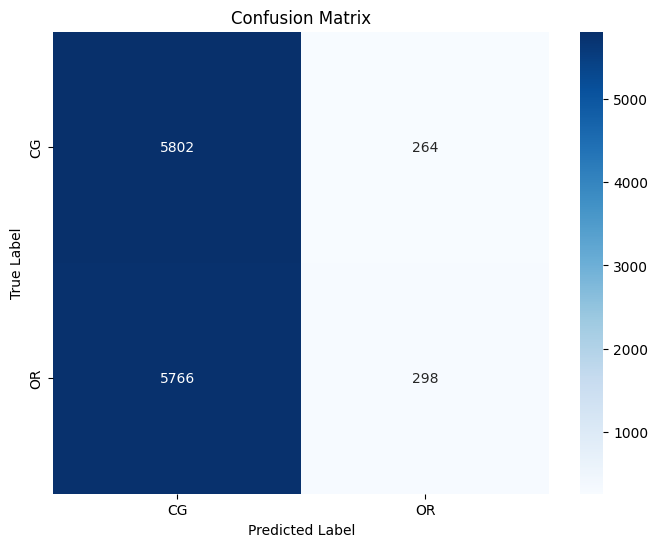

In [57]:
conf_matrix = confusion_matrix(y_test, KNN_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

decision tree

In [58]:
model2=DecisionTreeClassifier()
model2.fit(X_train_tfidf, y_train)

DecisionTreeClassifier()

In [59]:
DT_pred = model2.predict(X_test_tfidf)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, DT_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, DT_pred))

Accuracy: 72.46%

Classification Report:
              precision    recall  f1-score   support

          CG       0.72      0.74      0.73      6066
          OR       0.73      0.71      0.72      6064

    accuracy                           0.72     12130
   macro avg       0.72      0.72      0.72     12130
weighted avg       0.72      0.72      0.72     12130



In [60]:
precision = precision_score(y_test, DT_pred, average='macro')  # or 'micro' or 'weighted'
recall = recall_score(y_test, DT_pred, average='macro')  # or 'micro' or 'weighted'
f1 = f1_score(y_test, DT_pred, average='macro')  # or 'micro' or 'weighted'

print(f"\nPrecision (Macro): {precision:.2f}")
print(f"Recall (Macro): {recall:.2f}")
print(f"F1-Score (Macro): {f1:.2f}")


Precision (Macro): 0.72
Recall (Macro): 0.72
F1-Score (Macro): 0.72


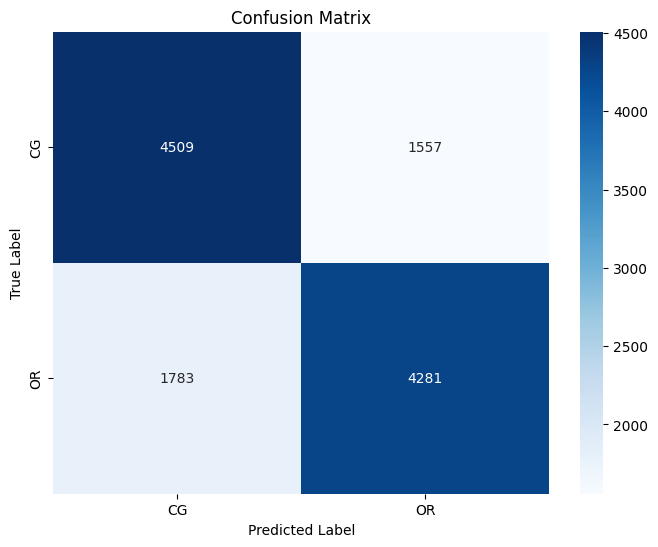

In [61]:
conf_matrix = confusion_matrix(y_test, DT_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

logistic regression

In [62]:
model3 = LogisticRegression()
model3.fit(X_train_tfidf, y_train)

LogisticRegression()

In [63]:
LR_pred = model3.predict(X_test_tfidf)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, LR_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, LR_pred))

Accuracy: 85.45%

Classification Report:
              precision    recall  f1-score   support

          CG       0.87      0.84      0.85      6066
          OR       0.84      0.87      0.86      6064

    accuracy                           0.85     12130
   macro avg       0.85      0.85      0.85     12130
weighted avg       0.85      0.85      0.85     12130



In [64]:
precision = precision_score(y_test, LR_pred, average='macro')  # or 'micro' or 'weighted'
recall = recall_score(y_test, LR_pred, average='macro')  # or 'micro' or 'weighted'
f1 = f1_score(y_test, LR_pred, average='macro')  # or 'micro' or 'weighted'

print(f"\nPrecision (Macro): {precision:.2f}")
print(f"Recall (Macro): {recall:.2f}")
print(f"F1-Score (Macro): {f1:.2f}")


Precision (Macro): 0.85
Recall (Macro): 0.85
F1-Score (Macro): 0.85


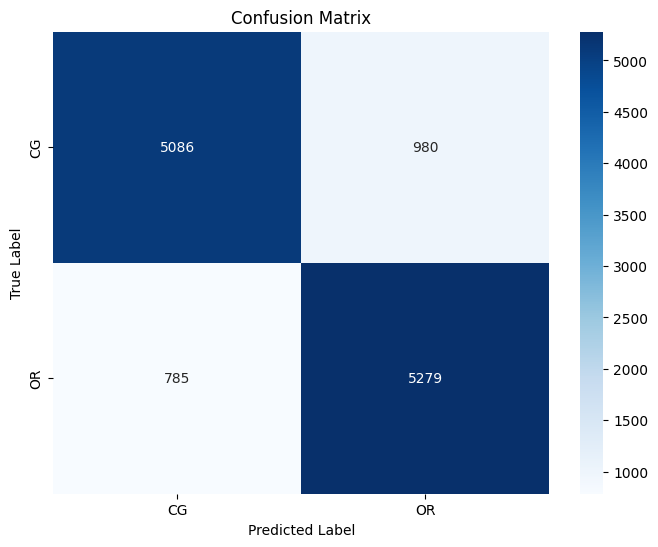

In [65]:
conf_matrix = confusion_matrix(y_test, LR_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Naive bayes

In [66]:
model4 = MultinomialNB()
model4.fit(X_train_tfidf, y_train)

MultinomialNB()

In [67]:
NB_pred = model4.predict(X_test_tfidf)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, NB_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, NB_pred))

Accuracy: 83.25%

Classification Report:
              precision    recall  f1-score   support

          CG       0.81      0.86      0.84      6066
          OR       0.85      0.80      0.83      6064

    accuracy                           0.83     12130
   macro avg       0.83      0.83      0.83     12130
weighted avg       0.83      0.83      0.83     12130



In [68]:
precision = precision_score(y_test, NB_pred, average='macro')  # or 'micro' or 'weighted'
recall = recall_score(y_test, NB_pred, average='macro')  # or 'micro' or 'weighted'
f1 = f1_score(y_test, NB_pred, average='macro')  # or 'micro' or 'weighted'

print(f"\nPrecision (Macro): {precision:.2f}")
print(f"Recall (Macro): {recall:.2f}")
print(f"F1-Score (Macro): {f1:.2f}")


Precision (Macro): 0.83
Recall (Macro): 0.83
F1-Score (Macro): 0.83


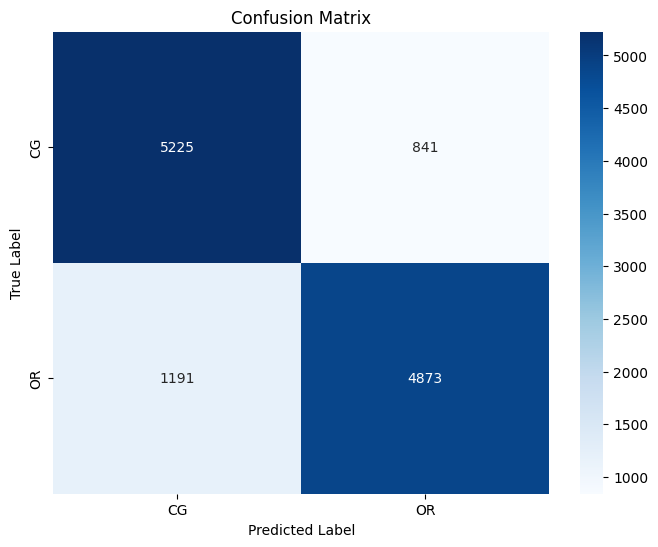

In [69]:
conf_matrix = confusion_matrix(y_test, NB_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [70]:
import joblib

# Save model
joblib.dump(model, 'random_forest_model.pkl')

# Save vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

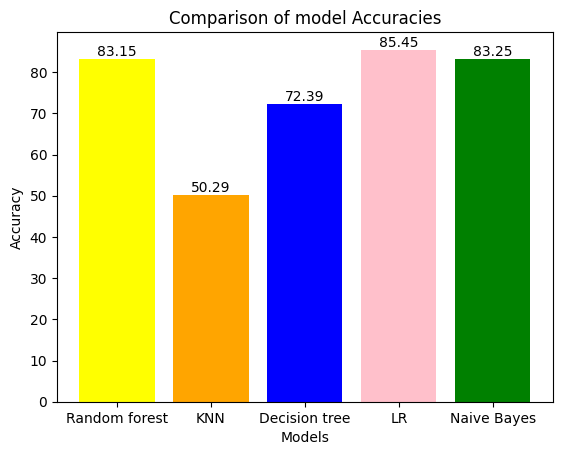

In [71]:
import matplotlib.pyplot as plt

accuracy_values=[83.15, 50.29, 72.39, 85.45, 83.25]
models = ['Random forest', 'KNN', 'Decision tree', 'LR', 'Naive Bayes']

plt.bar(models, accuracy_values, color=['yellow','orange','blue','pink','green'])

for i, value in enumerate(accuracy_values):
    plt.text(i,value+0.01, f'{value:.2f}',ha='center', va='bottom', fontsize=10)

    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.title('Comparison of model Accuracies')

plt.show()